# Experiment results

Read the current results written by the sole experiment command, `python scripts/run_experiment.py`.
The default table is `results/experiment/results.csv`; `INFLUENCE_RESULTS_DIR` can select
another output directory. Run cells from the top to compare scores, selected municipalities,
company activity, and company ablation. This notebook does not run seed optimization.

Network loading is shared with the runner. Propagation is reconstructed using **each saved
row's settings**, including its horizon and stopping rule. The discounted, population-weighted
score includes the seed state once; it is not a count of municipalities reached. For active
and cumulative reach over time, open `influence_maximization.ipynb`.

`RESULT_FILTERS` below selects a comparable slice when additional settings are saved;
alpha and seed-budget plots hold all other parameters fixed within each year.


In [1]:
from __future__ import annotations

import itertools
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "scripts/run_experiment.py").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.run_experiment import DEFAULT_OUTPUT_DIR, PARAMETER_COLUMNS, ExperimentConfig, load_results, load_year_model

configured_results_dir = os.environ.get("INFLUENCE_RESULTS_DIR")
RESULTS_DIR = (
    Path(configured_results_dir).expanduser().resolve()
    if configured_results_dir
    else DEFAULT_OUTPUT_DIR
)
RESULTS_PATH = RESULTS_DIR / "results.csv"
from src.gip_model import (
    GIPParameters, gip, company_activity,
)
from src.model_identity import evaluation_cache_key, input_fingerprint

RESULT_FILTERS = {}  # Example: {"horizon": 20, "stress_level": 0.0}; None selects early stopping.

RESULTS_PATH


PosixPath('/Users/matteobergamaschi/Desktop/rete_ipl_git/results/experiment/results.csv')

## Load and validate

In [2]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"No results found at {RESULTS_PATH}")

results = load_results(RESULTS_PATH)
for parameter, value in RESULT_FILTERS.items():
    if parameter not in ["year", *PARAMETER_COLUMNS]:
        raise ValueError(f"Unknown result filter: {parameter}")
    matches = results[parameter].isna() if value is None else results[parameter].eq(value)
    results = results.loc[matches].copy()
if results.empty:
    raise ValueError("No completed rows match RESULT_FILTERS")

other_parameters = [name for name in PARAMETER_COLUMNS if name not in ("alpha", "seed_budget")]
confounded = [name for name in other_parameters
              if results.groupby("year")[name].nunique(dropna=False).gt(1).any()]
if confounded:
    raise ValueError(f"Set RESULT_FILTERS to hold these settings fixed within each year: {confounded}")
for column in ["start_list", "finish_list"]:
    results[column] = results[column].map(json.loads)

INSTANCE_COLUMNS = ["year", *PARAMETER_COLUMNS]
VARYING_PARAMETERS = [column for column in PARAMETER_COLUMNS if results[column].nunique(dropna=False) > 1]
FIXED_PARAMETERS = [column for column in PARAMETER_COLUMNS if column not in VARYING_PARAMETERS]
YEARS = sorted(results["year"].astype(int).unique())

results["spread_gain"] = results["finish_spread"] - results["start_spread"]
results["spread_gain_pct"] = 100 * results["spread_gain"] / results["start_spread"]

def start_finish_metrics(row: pd.Series) -> pd.Series:
    start = set(int(value) for value in row["start_list"])
    finish = set(int(value) for value in row["finish_list"])
    return pd.Series({
        "retained_seeds": len(start & finish),
        "replaced_seeds": len(start - finish),
        "start_finish_jaccard": len(start & finish) / len(start | finish),
    })

results = pd.concat([results, results.apply(start_finish_metrics, axis=1)], axis=1)
municipalities = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "node_parameters.csv",
    usecols=["year", "municipality_id", "municipality_name"],
)
municipality_names = (
    municipalities.drop_duplicates(["year", "municipality_id"])
    .set_index(["year", "municipality_id"])["municipality_name"]
    .to_dict()
)

checks = pd.Series({
    "one row per year and full parameter instance": not results.duplicated(INSTANCE_COLUMNS).any(),
    "finite spread values": np.isfinite(results[["start_spread", "finish_spread"]]).all().all(),
    "finish spread is at least start spread": results["finish_spread"].ge(results["start_spread"]).all(),
    "start-list lengths match seed budget": results.apply(lambda row: len(row["start_list"]) == row["seed_budget"], axis=1).all(),
    "finish-list lengths match seed budget": results.apply(lambda row: len(row["finish_list"]) == row["seed_budget"], axis=1).all(),
}, name="passed")
display(checks.to_frame().style.map(lambda passed: "color: #1b7f3a" if passed else "color: #b42318"))
assert checks.all(), checks[~checks]


,passed
one row per year and full parameter instance,True
finite spread values,True
finish spread is at least start spread,True
start-list lengths match seed budget,True
finish-list lengths match seed budget,True


In [3]:
varying_values = pd.DataFrame({
    "values": [results[column].drop_duplicates().tolist() for column in VARYING_PARAMETERS],
    "count": [results[column].nunique(dropna=False) for column in VARYING_PARAMETERS],
}, index=VARYING_PARAMETERS)
fixed_values = results[FIXED_PARAMETERS].iloc[0].rename("value").to_frame() if FIXED_PARAMETERS else pd.DataFrame()
expected_rows = len(YEARS) * int(np.prod([results[column].nunique(dropna=False) for column in VARYING_PARAMETERS]))

overview = pd.Series({
    "saved rows": len(results),
    "full-grid rows expected": expected_rows,
    "grid complete": len(results) == expected_rows,
    "years": YEARS,
    "varied hyperparameters": VARYING_PARAMETERS,
}, name="value")
display(overview.to_frame())
display(Markdown("### Varied hyperparameters — these effects can be compared"))
display(varying_values)
display(Markdown("### Fixed hyperparameters — this experiment cannot estimate their effects"))
display(fixed_values)


,value
saved rows,9
full-grid rows expected,9
grid complete,True
years,[2023]
varied hyperparameters,"[alpha, seed_budget]"


### Varied hyperparameters — these effects can be compared

,values,count
alpha,"[0.05, 0.1, 0.2]",3
seed_budget,"[10, 20, 40]",3


### Fixed hyperparameters — this experiment cannot estimate their effects

,value
edge_weight_beta,0.500
node_weight_beta,0.500
min_edge_size,2.000
edge_weight_mean,1.000
node_weight_mean,1.000
h0,1.000
l0,1.000
theta_l,2.000
theta_h,50.000
gamma,0.100


## Spread outcomes

Finish spread describes the model outcome under each setting. Spread gain (%) isolates how much NaDS improved its deterministic starting list under that same setting. Because alpha changes the propagation thresholds themselves, finish-spread levels across alpha values represent both a model change and a seed-selection change.

In [4]:
outcome_columns = [
    "year", "alpha", "seed_budget", "horizon", "diffusion_iterations", "stopping_reason", "start_spread", "finish_spread",
    "spread_gain", "spread_gain_pct", "retained_seeds", "start_finish_jaccard",
]
display(results[outcome_columns].sort_values(["year", "alpha", "seed_budget"]).reset_index(drop=True))


,year,alpha,seed_budget,horizon,diffusion_iterations,stopping_reason,start_spread,finish_spread,spread_gain,spread_gain_pct,retained_seeds,start_finish_jaccard
0,2023,0.050,10,20,20,fixed_horizon,"6,002.099","7,846.787","1,844.688",30.734,2.000,0.111
1,2023,0.050,20,20,20,fixed_horizon,"7,144.623","10,199.368","3,054.746",42.756,3.000,0.081
2,2023,0.050,40,20,20,fixed_horizon,"8,261.287","12,384.312","4,123.025",49.908,14.000,0.212
3,2023,0.100,10,20,20,fixed_horizon,"14,126.892","17,922.150","3,795.258",26.865,2.000,0.111
4,2023,0.100,20,20,20,fixed_horizon,"16,524.702","21,752.360","5,227.659",31.635,5.000,0.143
5,2023,0.100,40,20,20,fixed_horizon,"18,557.287","26,387.446","7,830.159",42.195,12.000,0.176
6,2023,0.200,10,20,20,fixed_horizon,"45,125.346","54,313.462","9,188.116",20.361,4.000,0.250
7,2023,0.200,20,20,20,fixed_horizon,"50,551.174","63,297.068","12,745.894",25.214,5.000,0.143
8,2023,0.200,40,20,20,fixed_horizon,"54,266.927","67,758.901","13,491.974",24.862,19.000,0.311


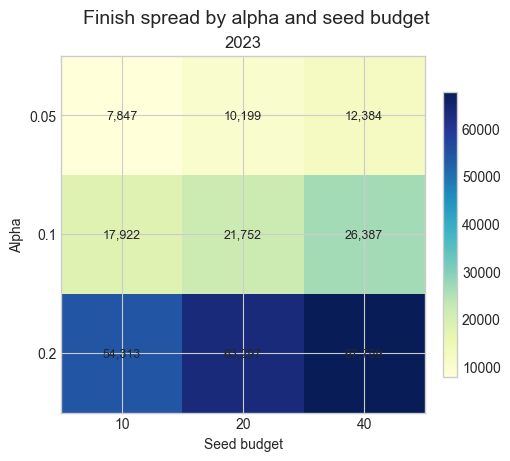

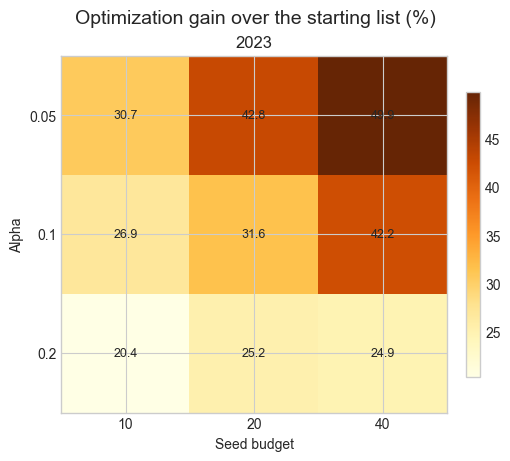

In [5]:
def parameter_heatmaps(metric: str, title: str, cmap: str, number_format: str) -> None:
    fig, axes = plt.subplots(1, len(YEARS), figsize=(5 * len(YEARS), 4.5), constrained_layout=True, squeeze=False)
    for axis, year in zip(axes.ravel(), YEARS):
        grid = (
            results.loc[results["year"].eq(year)]
            .pivot(index="alpha", columns="seed_budget", values=metric)
            .sort_index().sort_index(axis=1)
        )
        image = axis.imshow(grid.to_numpy(), aspect="auto", cmap=cmap)
        axis.set_xticks(np.arange(len(grid.columns)), labels=grid.columns)
        axis.set_yticks(np.arange(len(grid.index)), labels=grid.index)
        axis.set(xlabel="Seed budget", ylabel="Alpha", title=str(year))
        for row_index in range(len(grid.index)):
            for column_index in range(len(grid.columns)):
                value = grid.iloc[row_index, column_index]
                if pd.notna(value):
                    axis.text(column_index, row_index, format(value, number_format), ha="center", va="center", fontsize=9)
        fig.colorbar(image, ax=axis, shrink=0.8)
    fig.suptitle(title, fontsize=14)
    plt.show()

parameter_heatmaps("finish_spread", "Finish spread by alpha and seed budget", "YlGnBu", ",.0f")
parameter_heatmaps("spread_gain_pct", "Optimization gain over the starting list (%)", "YlOrBr", ".1f")


## Hyperparameter effects and interactions

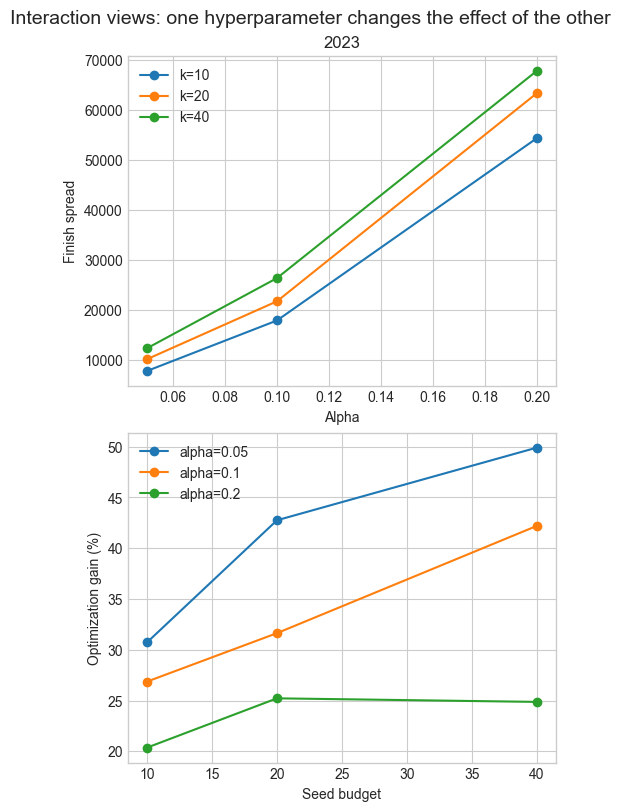

In [6]:
fig, axes = plt.subplots(2, len(YEARS), figsize=(5 * len(YEARS), 8), constrained_layout=True, squeeze=False)
for column_index, year in enumerate(YEARS):
    year_data = results.loc[results["year"].eq(year)]
    for budget, group in year_data.groupby("seed_budget"):
        group = group.sort_values("alpha")
        axes[0, column_index].plot(group["alpha"], group["finish_spread"], marker="o", label=f"k={budget}")
    for alpha, group in year_data.groupby("alpha"):
        group = group.sort_values("seed_budget")
        axes[1, column_index].plot(group["seed_budget"], group["spread_gain_pct"], marker="o", label=f"alpha={alpha:g}")
    axes[0, column_index].set(title=str(year), xlabel="Alpha", ylabel="Finish spread")
    axes[1, column_index].set(xlabel="Seed budget", ylabel="Optimization gain (%)")
    axes[0, column_index].legend()
    axes[1, column_index].legend()
fig.suptitle("Interaction views: one hyperparameter changes the effect of the other", fontsize=14)
plt.show()

In [7]:
alpha_effect_rows = []
for (year, budget), group in results.groupby(["year", "seed_budget"]):
    ordered = group.sort_values("alpha")
    low, high = ordered.iloc[0], ordered.iloc[-1]
    alpha_effect_rows.append({
        "year": year,
        "seed_budget": budget,
        "alpha_low": low["alpha"],
        "alpha_high": high["alpha"],
        "finish_spread_change": high["finish_spread"] - low["finish_spread"],
        "finish_spread_change_pct": 100 * (high["finish_spread"] / low["finish_spread"] - 1),
        "optimization_gain_change_pp": high["spread_gain_pct"] - low["spread_gain_pct"],
    })

budget_effect_rows = []
for (year, alpha), group in results.groupby(["year", "alpha"]):
    ordered = group.sort_values("seed_budget")
    low, high = ordered.iloc[0], ordered.iloc[-1]
    budget_effect_rows.append({
        "year": year,
        "alpha": alpha,
        "budget_low": int(low["seed_budget"]),
        "budget_high": int(high["seed_budget"]),
        "finish_spread_change": high["finish_spread"] - low["finish_spread"],
        "finish_spread_change_pct": 100 * (high["finish_spread"] / low["finish_spread"] - 1),
        "optimization_gain_change_pp": high["spread_gain_pct"] - low["spread_gain_pct"],
    })

display(Markdown("### Change from the lowest to highest alpha, holding year and seed budget fixed"))
display(pd.DataFrame(alpha_effect_rows))
display(Markdown("### Change from the smallest to largest seed budget, holding year and alpha fixed"))
display(pd.DataFrame(budget_effect_rows))

### Change from the lowest to highest alpha, holding year and seed budget fixed

,year,seed_budget,alpha_low,alpha_high,finish_spread_change,finish_spread_change_pct,optimization_gain_change_pp
0,2023,10,0.050,0.200,"46,466.675",592.175,-10.373
1,2023,20,0.050,0.200,"53,097.700",520.598,-17.542
2,2023,40,0.050,0.200,"55,374.589",447.135,-25.046


### Change from the smallest to largest seed budget, holding year and alpha fixed

,year,alpha,budget_low,budget_high,finish_spread_change,finish_spread_change_pct,optimization_gain_change_pp
0,2023,0.050,10,40,"4,537.525",57.827,19.174
1,2023,0.100,10,40,"8,465.296",47.234,15.329
2,2023,0.200,10,40,"13,445.439",24.755,4.501


## How hyperparameters change the optimized municipality set

In [8]:
pairwise_rows = []
for year, year_data in results.groupby("year"):
    for (index_a, row_a), (index_b, row_b) in itertools.combinations(year_data.iterrows(), 2):
        set_a = set(int(value) for value in row_a["finish_list"])
        set_b = set(int(value) for value in row_b["finish_list"])
        shared = set_a & set_b
        union = set_a | set_b
        changed_parameters = [
            parameter for parameter in VARYING_PARAMETERS
            if not (pd.isna(row_a[parameter]) and pd.isna(row_b[parameter]))
            and row_a[parameter] != row_b[parameter]
        ]
        pairwise_rows.append({
            "year": int(year),
            "result_a": int(index_a),
            "result_b": int(index_b),
            "changed_parameters": " + ".join(changed_parameters),
            "alpha_a": row_a["alpha"],
            "alpha_b": row_b["alpha"],
            "seed_budget_a": int(row_a["seed_budget"]),
            "seed_budget_b": int(row_b["seed_budget"]),
            "shared": len(shared),
            "jaccard": len(shared) / len(union),
            "smaller_set_containment": len(shared) / min(len(set_a), len(set_b)),
        })
pairwise = pd.DataFrame(pairwise_rows, columns=[
    "year", "result_a", "result_b", "changed_parameters", "alpha_a", "alpha_b",
    "seed_budget_a", "seed_budget_b", "shared", "jaccard", "smaller_set_containment",
])
pairwise_summary = (
    pairwise.groupby("changed_parameters")
    .agg(
        comparisons=("year", "size"),
        mean_jaccard=("jaccard", "mean"),
        min_jaccard=("jaccard", "min"),
        mean_smaller_set_containment=("smaller_set_containment", "mean"),
    )
    .sort_values("mean_jaccard")
)
display(pairwise_summary)


,comparisons,mean_jaccard,min_jaccard,mean_smaller_set_containment
changed_parameters,,,,
alpha + seed_budget,18,0.177,0.087,0.528
seed_budget,9,0.201,0.091,0.572
alpha,9,0.234,0.176,0.378


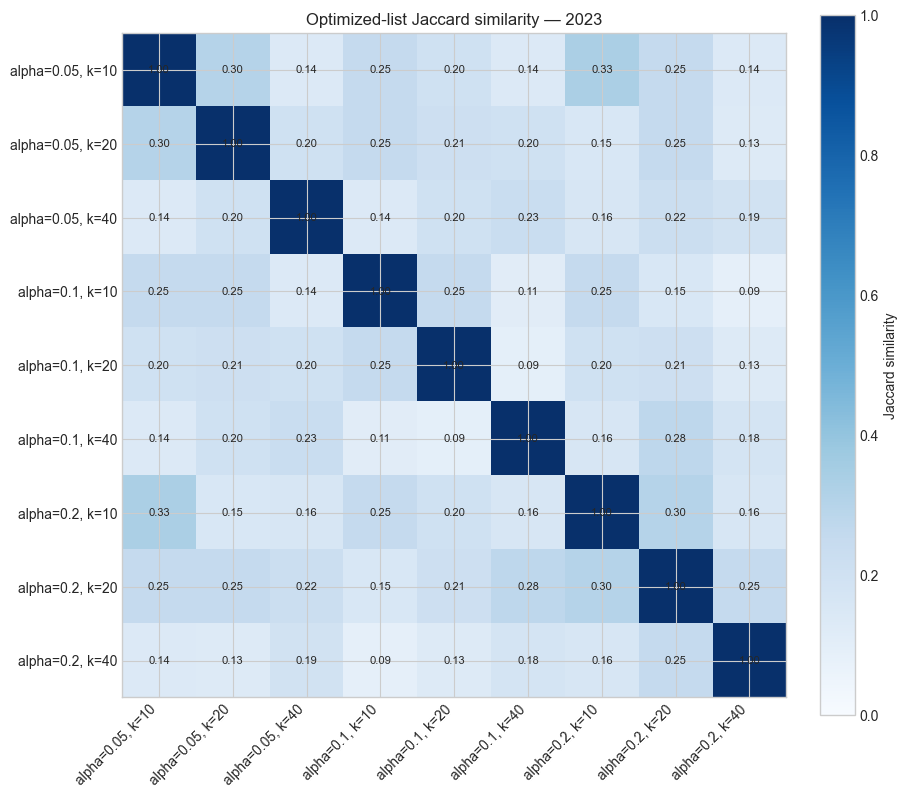

In [9]:
SELECTION_YEAR = max(YEARS)
selection_rows = results.loc[results["year"].eq(SELECTION_YEAR)].sort_values(["alpha", "seed_budget"])
selection_sets = [set(int(value) for value in values) for values in selection_rows["finish_list"]]
selection_labels = [f"alpha={row.alpha:g}, k={int(row.seed_budget)}" for row in selection_rows.itertuples()]
jaccard_matrix = np.eye(len(selection_sets))
for row_index, column_index in itertools.combinations(range(len(selection_sets)), 2):
    set_a, set_b = selection_sets[row_index], selection_sets[column_index]
    value = len(set_a & set_b) / len(set_a | set_b)
    jaccard_matrix[row_index, column_index] = value
    jaccard_matrix[column_index, row_index] = value

fig, axis = plt.subplots(figsize=(9, 8), constrained_layout=True)
image = axis.imshow(jaccard_matrix, cmap="Blues", vmin=0, vmax=1)
axis.set_xticks(np.arange(len(selection_labels)), labels=selection_labels, rotation=45, ha="right")
axis.set_yticks(np.arange(len(selection_labels)), labels=selection_labels)
axis.set_title(f"Optimized-list Jaccard similarity — {SELECTION_YEAR}")
for row_index in range(len(selection_labels)):
    for column_index in range(len(selection_labels)):
        axis.text(column_index, row_index, f"{jaccard_matrix[row_index, column_index]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Jaccard similarity")
plt.show()

## Municipalities robust to hyperparameter changes

,municipality_id,municipality_name,appearances,years,alpha_values,seed_budgets,mean_rank
0,145920351,COMUNE DI REGGIO NELL'EMILIA,9,1,3,3,2.000
1,215150236,COMUNE DI VERONA,9,1,3,3,3.111
2,2438750586,ROMA CAPITALE,9,1,3,3,4.111
3,168650307,COMUNE DI UDINE,7,1,3,3,5.429
4,80000330656,COMUNE DI SALERNO,7,1,3,3,10.857
5,1199250158,COMUNE DI MILANO,5,1,3,3,1.000
6,80002870774,COMUNE DI MATERA,5,1,3,3,6.800
7,80034840167,COMUNE DI BERGAMO,5,1,3,2,9.000
8,137020871,COMUNE DI CATANIA,5,1,3,3,22.800
9,761890177,COMUNE DI BRESCIA,4,1,3,3,1.000


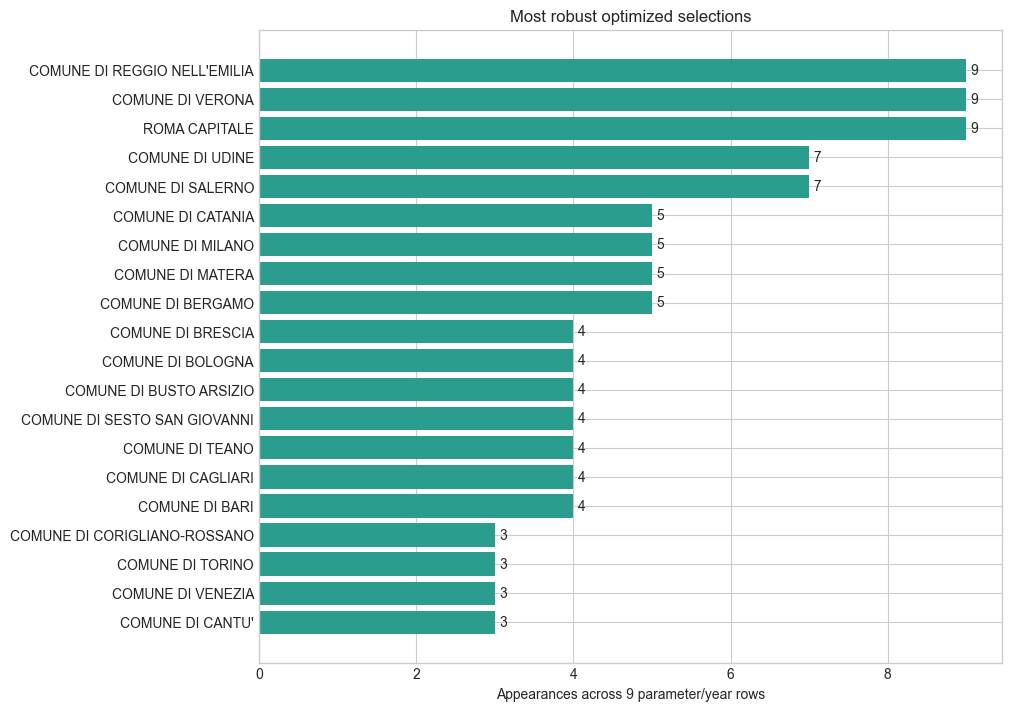

In [10]:
selection_entries = []
for result_index, row in results.iterrows():
    for rank, municipality_id in enumerate(row["finish_list"], start=1):
        municipality_id = int(municipality_id)
        selection_entries.append({
            "result_index": int(result_index),
            "year": int(row["year"]),
            "alpha": row["alpha"],
            "seed_budget": int(row["seed_budget"]),
            "municipality_id": municipality_id,
            "municipality_name": municipality_names.get((int(row["year"]), municipality_id), "unknown"),
            "rank": rank,
        })
selections = pd.DataFrame(selection_entries)
municipality_summary = (
    selections.groupby(["municipality_id", "municipality_name"])
    .agg(
        appearances=("result_index", "size"),
        years=("year", "nunique"),
        alpha_values=("alpha", "nunique"),
        seed_budgets=("seed_budget", "nunique"),
        mean_rank=("rank", "mean"),
    )
    .reset_index()
    .sort_values(["appearances", "years", "mean_rank"], ascending=[False, False, True])
)
display(municipality_summary.head(25).reset_index(drop=True))

plot_data = municipality_summary.head(20).sort_values("appearances")
fig, axis = plt.subplots(figsize=(10, 7), constrained_layout=True)
axis.barh(plot_data["municipality_name"], plot_data["appearances"], color="#2a9d8f")
axis.set(title="Most robust optimized selections", xlabel=f"Appearances across {len(results)} parameter/year rows")
axis.bar_label(axis.containers[0], padding=3)
plt.show()

## Inspect one parameter setting

In [11]:
INSPECT_YEAR = max(YEARS)
INSPECT_ALPHA = 0.10
INSPECT_SEED_BUDGET = 20

inspect_matches = results.loc[
    results["year"].eq(INSPECT_YEAR)
    & np.isclose(results["alpha"], INSPECT_ALPHA)
    & results["seed_budget"].eq(INSPECT_SEED_BUDGET)
]
if inspect_matches.empty:
    chosen_result = results.sort_values(["year", "alpha", "seed_budget"]).iloc[-1]
    INSPECT_YEAR = int(chosen_result["year"])
    INSPECT_ALPHA = float(chosen_result["alpha"])
    INSPECT_SEED_BUDGET = int(chosen_result["seed_budget"])
    display(Markdown("Preferred setting was not saved yet; using the latest available row."))
elif len(inspect_matches) > 1:
    raise ValueError("More than one row matches; filter another varied parameter as well")
else:
    chosen_result = inspect_matches.iloc[0]

CHOSEN_RESULT_INDEX = int(chosen_result.name)
start_ids = [int(value) for value in chosen_result["start_list"]]
finish_ids = [int(value) for value in chosen_result["finish_list"]]
start_set, finish_set = set(start_ids), set(finish_ids)
start_table = pd.DataFrame({
    "start_rank": range(1, len(start_ids) + 1),
    "municipality_id": start_ids,
    "municipality_name": [municipality_names.get((INSPECT_YEAR, value), "unknown") for value in start_ids],
    "status": ["retained" if value in finish_set else "removed" for value in start_ids],
})
finish_table = pd.DataFrame({
    "finish_rank": range(1, len(finish_ids) + 1),
    "municipality_id": finish_ids,
    "municipality_name": [municipality_names.get((INSPECT_YEAR, value), "unknown") for value in finish_ids],
    "status": ["retained" if value in start_set else "added" for value in finish_ids],
})
display(Markdown(f"### year={INSPECT_YEAR}, alpha={INSPECT_ALPHA:g}, seed_budget={INSPECT_SEED_BUDGET}"))
display(chosen_result[["start_spread", "finish_spread", "spread_gain_pct", "retained_seeds", "start_finish_jaccard"]].rename("value").to_frame())
display(Markdown("### Starting list"), start_table, Markdown("### Optimized list"), finish_table)

### year=2023, alpha=0.1, seed_budget=20

,value
start_spread,"16,524.702"
finish_spread,"21,752.360"
spread_gain_pct,31.635
retained_seeds,5.000
start_finish_jaccard,0.143


### Starting list

,start_rank,municipality_id,municipality_name,status
0,1,168650307,COMUNE DI UDINE,retained
1,2,516890241,COMUNE DI VICENZA,retained
2,3,761890177,COMUNE DI BRESCIA,retained
3,4,2253930156,COMUNE DI SESTO SAN GIOVANNI,removed
4,5,524950177,COMUNE DI CALCINATO,removed
5,6,145920351,COMUNE DI REGGIO NELL'EMILIA,retained
6,7,645400177,COMUNE DI MONTICHIARI,removed
7,8,80004590677,COMUNE DI CROGNALETO,removed
8,9,159200674,COMUNE DI PINETO,removed
9,10,644060287,COMUNE DI PADOVA,removed


### Optimized list

,finish_rank,municipality_id,municipality_name,status
0,1,761890177,COMUNE DI BRESCIA,retained
1,2,145920351,COMUNE DI REGGIO NELL'EMILIA,retained
2,3,215150236,COMUNE DI VERONA,added
3,4,2438750586,ROMA CAPITALE,added
4,5,1232710374,COMUNE DI BOLOGNA,added
5,6,168650307,COMUNE DI UDINE,retained
6,7,516890241,COMUNE DI VICENZA,retained
7,8,224000125,COMUNE DI BUSTO ARSIZIO,added
8,9,80005990611,COMUNE DI TEANO,added
9,10,172340069,COMUNE DI CASALE MONFERRATO,added


## Companies most involved in propagation

For every saved result, this section reconstructs propagation from its optimized municipality list. Company activity is time-discounted raw return to other shareholders, before municipal thresholds and population valuation. It excludes direct self-return and is a diagnostic, not a decomposition of the nonlinear objective. The final ablation comparison removes candidate companies one at a time and measures lost spread across alpha settings at a fixed year and seed budget.
The input fingerprint is an in-memory checksum of the three input files, used only to invalidate cached reconstructions after a file changes. It is not a model parameter and is not written to results.


In [12]:
MODEL_CACHE = {}
PROPAGATION_CACHE = {}

def model_for_row(row: pd.Series) -> dict[str, object]:
    fingerprint = input_fingerprint(PROJECT_ROOT / "data" / "processed", int(row["year"]))
    key = (
        fingerprint,
        int(row["year"]), int(row["min_edge_size"]),
        float(row["edge_weight_mean"]), float(row["edge_weight_beta"]),
        float(row["node_weight_mean"]), float(row["node_weight_beta"]),
    )
    if key in MODEL_CACHE:
        return MODEL_CACHE[key]

    config = ExperimentConfig(
        min_edge_size=int(row["min_edge_size"]),
        edge_weight_mean=float(row["edge_weight_mean"]), edge_weight_beta=float(row["edge_weight_beta"]),
        node_weight_mean=float(row["node_weight_mean"]), node_weight_beta=float(row["node_weight_beta"]),
    )
    model = load_year_model(int(row["year"]), config, data_dir=PROJECT_ROOT / "data" / "processed")
    model["source_key"] = key
    MODEL_CACHE[key] = model
    return model

def propagation_for_row(result_index: int, row: pd.Series) -> dict[str, object]:
    model = model_for_row(row)
    seed_ids = set(int(value) for value in row["finish_list"])
    missing = seed_ids - set(model["node_ids"])
    if missing or len(seed_ids) != int(row["seed_budget"]):
        raise ValueError(f"Saved seed list does not match the current network/budget; missing IDs: {sorted(missing)}")
    seed_state = np.isin(model["node_ids"], list(seed_ids)).astype(float) * float(row["seed_intensity"])
    parameters = GIPParameters(
        h0=float(row["h0"]), l0=float(row["l0"]),
        theta_l=float(row["theta_l"]), theta_h=float(row["theta_h"]),
        gamma=float(row["gamma"]), eps=float(row["eps"]),
    )
    horizon = None if pd.isna(row["horizon"]) else int(row["horizon"])
    max_iter = int(row["max_iter"])
    score_key = evaluation_cache_key(
        model["incidence"], model["edge_weights"], seed_state, parameters,
        node_weights=model["node_weights"], stress_level=float(row["stress_level"]),
        alpha=float(row["alpha"]), horizon=horizon, max_iter=max_iter,
    )
    key = (model["source_key"], score_key)
    if key in PROPAGATION_CACHE:
        return PROPAGATION_CACHE[key]
    propagation = gip(
        model["incidence"], model["edge_weights"], seed_state, parameters,
        node_weights=model["node_weights"], stress_level=float(row["stress_level"]), alpha=float(row["alpha"]),
        horizon=horizon, max_iter=max_iter,
    )
    activity = np.zeros(model["incidence"].shape[1])
    active_steps = np.zeros(model["incidence"].shape[1], dtype=int)
    for step, state in enumerate(propagation.states[:-1], start=1):
        pressure = np.asarray(model["incidence"]._matrix.T @ state).reshape(-1)
        active_steps += (pressure > float(row["stress_level"])).astype(int)
        activity += (1 - parameters.gamma) ** step * company_activity(
            model["incidence"], model["edge_weights"], state, float(row["stress_level"])
        )
    metrics = model["edge_audit"].reset_index().copy()
    metrics["activity"] = activity
    metrics["activity_share_pct"] = 100 * activity / activity.sum() if activity.sum() else 0.0
    metrics["activity_rank"] = metrics["activity"].rank(method="min", ascending=False)
    metrics["active_steps"] = active_steps
    output = {"model": model, "seed_state": seed_state, "propagation": propagation, "metrics": metrics, "parameters": parameters, "horizon": horizon, "max_iter": max_iter}
    PROPAGATION_CACHE[key] = output
    return output


In [13]:
activity_frames = []
reconstruction_checks = []
for result_index, row in results.iterrows():
    reconstructed = propagation_for_row(int(result_index), row)
    metrics = reconstructed["metrics"].copy()
    metrics["result_index"] = int(result_index)
    metrics["year"] = int(row["year"])
    metrics["alpha"] = float(row["alpha"])
    metrics["seed_budget"] = int(row["seed_budget"])
    activity_frames.append(metrics)
    reconstruction_checks.append({
        "result_index": int(result_index),
        "saved_finish_spread": row["finish_spread"],
        "reconstructed_finish_spread": reconstructed["propagation"].total_spread,
        "absolute_difference": abs(row["finish_spread"] - reconstructed["propagation"].total_spread),
    })
company_activities = pd.concat(activity_frames, ignore_index=True)
reconstruction_checks = pd.DataFrame(reconstruction_checks)
assert reconstruction_checks["absolute_difference"].max() < 1e-6, "Saved scores differ from current data/settings"
display(reconstruction_checks)

company_summary = (
    company_activities.groupby(["company_id", "company_name"])
    .agg(
        runs_present=("result_index", "nunique"),
        top_20_appearances=("activity_rank", lambda values: int(values.le(20).sum())),
        mean_activity_rank=("activity_rank", "mean"),
        mean_activity_share_pct=("activity_share_pct", "mean"),
        max_activity_share_pct=("activity_share_pct", "max"),
    )
    .reset_index()
    .sort_values(["top_20_appearances", "mean_activity_rank"], ascending=[False, True])
)
display(Markdown("### Companies consistently active across hyperparameter settings"))
display(company_summary.head(20).reset_index(drop=True))


,result_index,saved_finish_spread,reconstructed_finish_spread,absolute_difference
0,0,"7,846.787","7,846.787",0.000
1,1,"10,199.368","10,199.368",0.000
2,2,"12,384.312","12,384.312",0.000
3,3,"17,922.150","17,922.150",0.000
4,4,"21,752.360","21,752.360",0.000
5,5,"26,387.446","26,387.446",0.000
6,6,"54,313.462","54,313.462",0.000
7,7,"63,297.068","63,297.068",0.000
8,8,"67,758.901","67,758.901",0.000


### Companies consistently active across hyperparameter settings

,company_id,company_name,runs_present,top_20_appearances,mean_activity_rank,mean_activity_share_pct,max_activity_share_pct
0,2460240357,S.A.BA.R. SERVIZI SRL,9,9,8.667,0.236,0.276
1,3567090232,ACQUE VERONESI S.C.A R.L.,9,8,11.778,0.233,0.289
2,13187590156,CAP HOLDING SOCIETA' PER AZIONI - IN FORMA ABBREVIATA CAP HOLDINGS.P.A.,9,8,12.556,0.228,0.270
3,158530303,CAFC S.P.A.,9,8,55.000,0.245,0.330
4,1589850351,"""S.A.BA.R. S.P.A.""",9,7,12.556,0.230,0.270
5,2132350022,S.E.A.B. SOCIETA' ECOLOGICA AREA BIELLESE S.P.A.,9,7,13.667,0.229,0.273
6,2197250208,SERVIZIO IDRICO INTEGRATO COMUNI ALTO MANTOVANO - S.I.C.A.M. S.R.L.,9,7,61.444,0.210,0.277
7,2296760974,CONSIAG SERVIZI COMUNI SRL,9,6,19.556,0.220,0.252
8,3278040245,ENERGIA TERRITORIO RISORSE AMBIENTALI - ETRA S.P.A.,9,6,20.778,0.237,0.293
9,5494610966,EURO.PA SERVICE SRL,9,6,22.444,0.219,0.266


### Company propagation share across alpha — year=2023, seed_budget=20

alpha,0.050,0.100,0.200
company_name,,,
CAFC S.P.A.,0.257,0.280,0.251
ENERGIA TERRITORIO RISORSE AMBIENTALI - ETRA S.P.A.,0.270,0.263,0.188
SOCIETA' ABRUZZESE PER SERVIZIO IDRICO INTEGRATO SPA - IN BREVE S.A.S.I. - S.P.A.,0.262,0.048,0.094
COMO ACQUA SRL,0.103,0.260,0.231
COSMARI SRL - SOCIETA' A RESPONSABILITA' LIMITATA,0.259,0.053,0.141
SILEA SPA - SOCIETA' INTERCOMUNALE LECCHESE PER L'ECOLOGIA E L'AMBIENTE PER AZIONI,0.259,0.228,0.195
A.C.A. S.P.A. IN HOUSE PROVIDING,0.257,0.048,0.193
AZIENDA GARDESANA SERVIZI S.P.A. IN BREVE A.G.S. S.P.A.,0.177,0.254,0.237
ACQUE VERONESI S.C.A R.L.,0.247,0.231,0.208


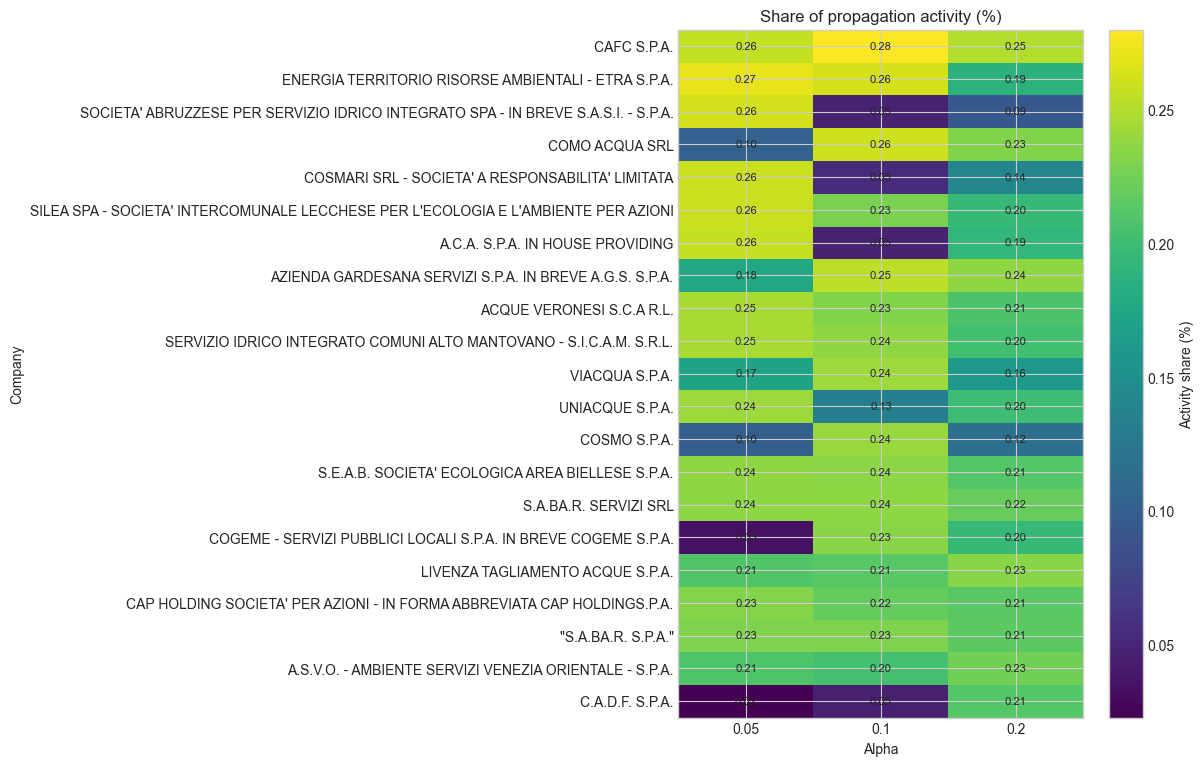

In [14]:
COMPANY_YEAR = INSPECT_YEAR
COMPANY_SEED_BUDGET = INSPECT_SEED_BUDGET
company_comparison = company_activities.loc[
    company_activities["year"].eq(COMPANY_YEAR)
    & company_activities["seed_budget"].eq(COMPANY_SEED_BUDGET)
].copy()
top_company_ids = set(
    company_comparison.sort_values("activity_rank").groupby("alpha").head(10)["company_id"]
)
activity_pivot = (
    company_comparison.loc[company_comparison["company_id"].isin(top_company_ids)]
    .pivot_table(index="company_name", columns="alpha", values="activity_share_pct", aggfunc="mean")
)
activity_pivot = activity_pivot.loc[activity_pivot.max(axis=1).sort_values(ascending=False).index]
display(Markdown(f"### Company propagation share across alpha — year={COMPANY_YEAR}, seed_budget={COMPANY_SEED_BUDGET}"))
display(activity_pivot)

fig, axis = plt.subplots(figsize=(11, max(6, 0.42 * len(activity_pivot))))
image = axis.imshow(activity_pivot.to_numpy(), aspect="auto", cmap="viridis")
axis.set_xticks(np.arange(len(activity_pivot.columns)), labels=activity_pivot.columns)
axis.set_yticks(np.arange(len(activity_pivot.index)), labels=activity_pivot.index)
axis.set(xlabel="Alpha", ylabel="Company", title="Share of propagation activity (%)")
for row_index in range(len(activity_pivot.index)):
    for column_index in range(len(activity_pivot.columns)):
        axis.text(column_index, row_index, f"{activity_pivot.iloc[row_index, column_index]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Activity share (%)")
fig.subplots_adjust(left=0.42, right=0.88, bottom=0.12, top=0.90)
plt.show()


### Company ablation across alpha

Ablation spread loss is the model spread removed when one company transmission weight is set to zero. It is conditional on each alpha-specific optimized municipality list and is not a causal estimate.

alpha,0.050,0.100,0.200
company_name,,,
NEUTALIA S.R.L,1.286,4.143,0.030
UNIACQUE S.P.A.,2.704,0.066,1.436
VIACQUA S.P.A.,0.000,0.822,0.000
COMO ACQUA SRL,0.026,0.705,0.487
CAFC S.P.A.,0.555,0.149,0.195
SOCIETA' ABRUZZESE PER SERVIZIO IDRICO INTEGRATO SPA - IN BREVE S.A.S.I. - S.P.A.,0.376,0.080,0.087
A.C.A. S.P.A. IN HOUSE PROVIDING,0.372,0.000,0.258
COSMARI SRL - SOCIETA' A RESPONSABILITA' LIMITATA,0.345,0.030,0.033
CAP HOLDING SOCIETA' PER AZIONI - IN FORMA ABBREVIATA CAP HOLDINGS.P.A.,0.017,0.000,0.273


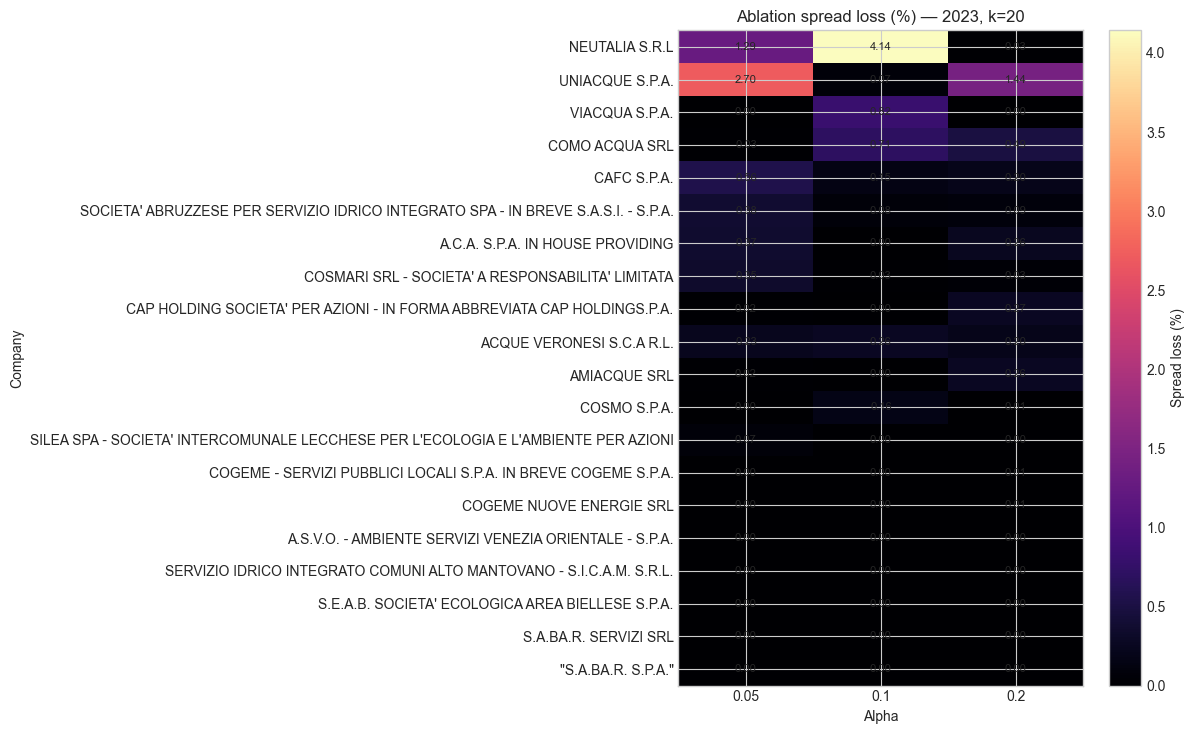

In [15]:
ABLATION_CANDIDATES_PER_ALPHA = 15
comparison_result_rows = results.loc[
    results["year"].eq(COMPANY_YEAR)
    & results["seed_budget"].eq(COMPANY_SEED_BUDGET)
].sort_values("alpha")
candidate_company_ids = set()
for result_index, row in comparison_result_rows.iterrows():
    metrics = propagation_for_row(int(result_index), row)["metrics"]
    candidate_company_ids.update(metrics.nlargest(ABLATION_CANDIDATES_PER_ALPHA, "activity")["company_id"].tolist())

ablation_rows = []
for result_index, row in comparison_result_rows.iterrows():
    reconstructed = propagation_for_row(int(result_index), row)
    model = reconstructed["model"]
    baseline_spread = reconstructed["propagation"].total_spread
    metrics = reconstructed["metrics"]
    company_to_edge = metrics.reset_index().set_index("company_id")["index"].to_dict()
    for company_id in sorted(candidate_company_ids):
        if company_id not in company_to_edge:
            continue
        edge_index = int(company_to_edge[company_id])
        ablated_weights = model["edge_weights"].copy()
        ablated_weights[edge_index] = 0.0
        ablated = gip(
            model["incidence"], ablated_weights, reconstructed["seed_state"], reconstructed["parameters"],
            node_weights=model["node_weights"], stress_level=float(row["stress_level"]), alpha=float(row["alpha"]),
            horizon=reconstructed["horizon"], max_iter=reconstructed["max_iter"],
        )
        company_row = metrics.iloc[edge_index]
        loss = baseline_spread - ablated.total_spread
        ablation_rows.append({
            "alpha": float(row["alpha"]),
            "company_id": company_id,
            "company_name": company_row["company_name"],
            "ablation_spread_loss": loss,
            "ablation_spread_loss_pct": 100 * loss / baseline_spread,
        })
company_ablation = pd.DataFrame(ablation_rows)
ablation_pivot = company_ablation.pivot_table(
    index="company_name", columns="alpha", values="ablation_spread_loss_pct", aggfunc="mean"
)
ablation_pivot = ablation_pivot.loc[ablation_pivot.max(axis=1).sort_values(ascending=False).head(20).index]
display(ablation_pivot)

fig, axis = plt.subplots(figsize=(11, max(6, 0.42 * len(ablation_pivot))))
image = axis.imshow(ablation_pivot.to_numpy(), aspect="auto", cmap="magma")
axis.set_xticks(np.arange(len(ablation_pivot.columns)), labels=ablation_pivot.columns)
axis.set_yticks(np.arange(len(ablation_pivot.index)), labels=ablation_pivot.index)
axis.set(xlabel="Alpha", ylabel="Company", title=f"Ablation spread loss (%) — {COMPANY_YEAR}, k={COMPANY_SEED_BUDGET}")
for row_index in range(len(ablation_pivot.index)):
    for column_index in range(len(ablation_pivot.columns)):
        value = ablation_pivot.iloc[row_index, column_index]
        if pd.notna(value):
            axis.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Spread loss (%)")
fig.subplots_adjust(left=0.42, right=0.88, bottom=0.12, top=0.90)
plt.show()

## Interpretation guide

- Use spread gain (%) to compare optimization effectiveness within a model setting.
- Use finish spread to describe the outcome produced by a setting, remembering that alpha changes the propagation model itself.
- Low Jaccard similarity means the optimized municipality recommendation is sensitive to the changed hyperparameter.
- Smaller-set containment is more informative than Jaccard when comparing different seed budgets.
- Company activity and ablation rankings are conditional on the model parameters and selected seed list; they are descriptive model outputs, not causal effects.
- Fixed-horizon seed-set monotonicity does not automatically apply to seed-dependent numerical truncation. Use the same horizon for theoretical comparisons.
